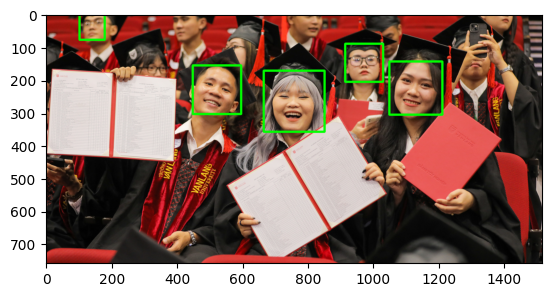

In [ ]:
import cv2
import matplotlib.pyplot as TNKY
img = cv2.imread("/content/Img.png")
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# dots that would look like STOP signs
stop_data = cv2.CascadeClassifier('/content/haarcascade_frontalface_default.xml')
found = stop_data.detectMultiScale(img_gray,minSize =(20, 20))
amount_found = len(found)

if amount_found != 0:
  for (x, y, width, height) in found:
      cv2.rectangle(img_rgb, (x, y),
      (x + height, y + width),
      (0, 255, 0), 5)
TNKY.imshow(img_rgb)

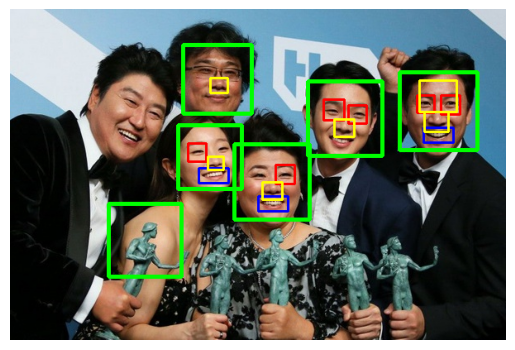

In [15]:
# 2. (Cập nhật: Thêm nhận diện Mũi)
import cv2
import matplotlib.pyplot as TNKY

# Đọc ảnh (Nhớ đổi tên ảnh thành hinh2.jpg hoặc Img.png cho đúng file bạn có)
img = cv2.imread("/content/img6.jpg")
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Load các bộ phân loại
face_data = cv2.CascadeClassifier("/content/haarcascade_frontalface_default.xml")
eye_data = cv2.CascadeClassifier("/content/haarcascade_eye.xml")
smile_data = cv2.CascadeClassifier("/content/haarcascade_smile.xml")

# --- THÊM: Load file nhận diện Mũi ---
# Lưu ý: Nếu môi trường Colab không có mcs_nose, Lil có thể cần tải file xml về máy ảo
nose_data = cv2.CascadeClassifier("/content/haarcascade_mcs_nose.xml")

found = face_data.detectMultiScale(img_gray, minSize=(20, 20))
amount_found = len(found)

if amount_found != 0:
    for (x, y, width, height) in found:
        # Vẽ khung khuôn mặt (Màu Xanh lá)
        cv2.rectangle(img_rgb, (x, y), (x + width, y + height), (0, 255, 0), 3)

        # Cắt vùng ROI (vùng khuôn mặt) để tìm các bộ phận khác
        roi_gray = img_gray[y:y+height, x:x+width]
        roi_color = img_rgb[y:y+height, x:x+width]

        # 1. Detect mắt (Màu Xanh dương)
        eyes = eye_data.detectMultiScale(roi_gray)
        for (ex, ey, ew, eh) in eyes:
            cv2.rectangle(roi_color, (ex, ey), (ex + ew, ey + eh), (255, 0, 0), 2)

        # 2. Detect miệng / nụ cười (Màu Đỏ)
        smiles = smile_data.detectMultiScale(roi_gray, 1.8, 20)
        for (sx, sy, sw, sh) in smiles:
            cv2.rectangle(roi_color, (sx, sy), (sx + sw, sy + sh), (0, 0, 255), 2)

        # --- 3. THÊM: Detect Mũi (Màu Vàng) ---
        noses = nose_data.detectMultiScale(roi_gray, 1.3, 5)
        for (nx, ny, nw, nh) in noses:
            cv2.rectangle(roi_color, (nx, ny), (nx + nw, ny + nh), (255, 255, 0), 2)

TNKY.imshow(img_rgb)
TNKY.axis("off")
TNKY.show()